In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from torchvision.models import convnext_tiny
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit


In [3]:
# Import du dataset numpy
directory = "C:/Users/lrozier/Documents/UQAC/respiratory-disease-detection/data/processed/"
X_features = np.load(directory + "X_features.npy")
X_mel = np.load(directory + "X_mel.npy")
y = np.load(directory + "y.npy")

print("Forme de X_features :", X_features.shape)
print("Forme de X_mel :", X_mel.shape)
print("Forme de y :", y.shape)

Forme de X_features : (1208, 16)
Forme de X_mel : (1208, 128, 259)
Forme de y : (1208,)


In [4]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

# Affichez la correspondance pour vérifier
for i, class_name in enumerate(le.classes_):
    print(f"Classe {i} : {class_name}")


Classe 0 : asthma
Classe 1 : bronchial
Classe 2 : copd
Classe 3 : healthy
Classe 4 : pneumonia


In [5]:
# Split en train, validation et test
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(split1.split(X_mel, y_encoded))

X_train, X_temp = X_mel[train_idx], X_mel[temp_idx]
y_train, y_temp = y_encoded[train_idx], y_encoded[temp_idx]

split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(split2.split(X_temp, y_temp))

X_val, X_test = X_temp[val_idx], X_temp[test_idx]
y_val, y_test = y_temp[val_idx], y_temp[test_idx]

In [6]:
print("Forme de X_train :", X_train.shape)

Forme de X_train : (845, 128, 259)


In [51]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 1. Préparation finale des tenseurs
# On s'assure d'avoir (B, 1, 128, 259)

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1) if X_train.ndim == 3 else torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1) if X_val.ndim == 3 else torch.tensor(X_val, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, torch.tensor(y_train, dtype=torch.long)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, torch.tensor(y_val, dtype=torch.long)), batch_size=64)


# 2. Configuration du modèle
device = "cuda" if torch.cuda.is_available() else "cpu"
model = convnext_tiny(pretrained=False)

# Adaptation de l'entrée (3 canaux -> 1 canal)
first_conv = model.features[0][0]
model.features[0][0] = nn.Conv2d(1, first_conv.out_channels, kernel_size=4, stride=4)
with torch.no_grad():
    model.features[0][0].weight.data = first_conv.weight.data.mean(dim=1, keepdim=True)


# Adaptation de la sortie (5 classes)
model.classifier = nn.Sequential(
    nn.Flatten(1),
    nn.LayerNorm((768,), eps=1e-6, elementwise_affine=True),
    nn.Flatten(1),
    nn.Linear(768, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 5)
)

model = model.to(device)


criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-6)

print(f"Entraînement sur : {torch.cuda.get_device_name(0)}")


for param in model.parameters():
    param.requires_grad = True

for epoch in range(150):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    print(f"Epoch {epoch+1}/150, Loss: {loss.item():.4f}")

c:\Users\lrozier\Documents\UQAC\respiratory-disease-detection\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lrozier\Documents\UQAC\respiratory-disease-detection\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Entraînement sur : NVIDIA GeForce RTX 4070 SUPER
Epoch 1/150, Loss: 1.5973
Epoch 2/150, Loss: 1.3356
Epoch 3/150, Loss: 1.5383
Epoch 4/150, Loss: 1.3818
Epoch 5/150, Loss: 1.5265
Epoch 6/150, Loss: 1.6651
Epoch 7/150, Loss: 1.5931
Epoch 8/150, Loss: 1.3299
Epoch 9/150, Loss: 1.2891
Epoch 10/150, Loss: 1.4407
Epoch 11/150, Loss: 1.6270
Epoch 12/150, Loss: 1.6922
Epoch 13/150, Loss: 1.4380
Epoch 14/150, Loss: 1.6605
Epoch 15/150, Loss: 1.6267
Epoch 16/150, Loss: 1.3235
Epoch 17/150, Loss: 1.3893
Epoch 18/150, Loss: 1.4923
Epoch 19/150, Loss: 1.4368
Epoch 20/150, Loss: 1.2833
Epoch 21/150, Loss: 1.4631
Epoch 22/150, Loss: 1.5816
Epoch 23/150, Loss: 1.3152
Epoch 24/150, Loss: 1.4769
Epoch 25/150, Loss: 1.3924
Epoch 26/150, Loss: 1.3084
Epoch 27/150, Loss: 1.7259
Epoch 28/150, Loss: 1.4754
Epoch 29/150, Loss: 1.4721
Epoch 30/150, Loss: 1.0897
Epoch 31/150, Loss: 1.3140
Epoch 32/150, Loss: 1.1087
Epoch 33/150, Loss: 0.9934
Epoch 34/150, Loss: 1.1794
Epoch 35/150, Loss: 1.4248
Epoch 36/150, L

ÉVALUATION DU MODÈLE

Accuracy globale:        0.7967
Macro F1-score:          0.7801  <- Métrique clé en médecine
Weighted F1-score:       0.7974

RAPPORT DE CLASSIFICATION PAR CLASSE

(Sensibilité = Recall = % de vrais positifs détectés par classe)
              precision    recall  f1-score   support

      asthma     0.7660    0.8372    0.8000        43
   bronchial     0.7143    0.6250    0.6667        16
        copd     0.9038    0.7833    0.8393        60
     healthy     0.8421    0.8000    0.8205        20
   pneumonia     0.7200    0.8372    0.7742        43

    accuracy                         0.7967       182
   macro avg     0.7892    0.7766    0.7801       182
weighted avg     0.8044    0.7967    0.7974       182



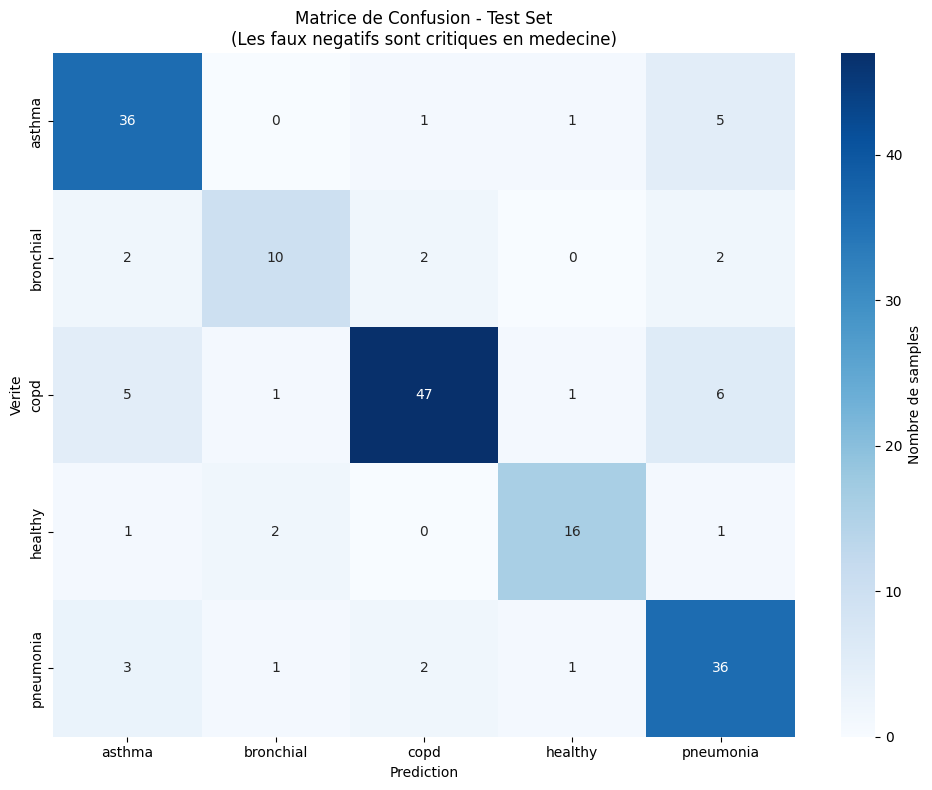


ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE
asthma         : FN=  7, TP= 36, Sensibilite=0.8372
bronchial      : FN=  6, TP= 10, Sensibilite=0.6250
copd           : FN= 13, TP= 47, Sensibilite=0.7833
healthy        : FN=  4, TP= 16, Sensibilite=0.8000
pneumonia      : FN=  7, TP= 36, Sensibilite=0.8372

AUC-ROC PAR CLASSE
asthma         : AUC-ROC = 0.9442
bronchial      : AUC-ROC = 0.8784
copd           : AUC-ROC = 0.9656
healthy        : AUC-ROC = 0.9813
pneumonia      : AUC-ROC = 0.9273

Moyenne AUC-ROC: 0.9394


In [52]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score)
import seaborn as sns


X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) if X_test.ndim == 3 else torch.tensor(X_test, dtype=torch.float32)

test_loader = DataLoader(TensorDataset(X_test_t, torch.tensor(y_test, dtype=torch.long)), batch_size=64, shuffle=False)


# Faire les prédictions sur le test set
model.eval()
y_test_pred = []
y_test_proba = []

with torch.no_grad():
    for specs, labels in test_loader:
        specs = specs.to(device, non_blocking=True)
        with torch.amp.autocast(device):
            outputs = model(specs)
        proba = torch.nn.functional.softmax(outputs, dim=1)
        y_test_pred.extend(outputs.argmax(dim=1).cpu().numpy())
        y_test_proba.extend(proba.cpu().numpy())

y_test_pred = np.array(y_test_pred)
y_test_proba = np.array(y_test_proba)

print("="*70)
print("ÉVALUATION DU MODÈLE")
print("="*70)

accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAccuracy globale:        {accuracy:.4f}")
print(f"Macro F1-score:          {macro_f1:.4f}  <- Métrique clé en médecine")
print(f"Weighted F1-score:       {weighted_f1:.4f}")

print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION PAR CLASSE")
print("="*70)
print("\n(Sensibilité = Recall = % de vrais positifs détectés par classe)")
print(classification_report(y_test, y_test_pred,
                          target_names=le.classes_,
                          digits=4,
                          zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Nombre de samples'}, ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite')
ax.set_title('Matrice de Confusion - Test Set\n(Les faux negatifs sont critiques en medecine)')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSE DES ERREURS - FAUX NÉGATIFS PAR CLASSE")
print("="*70)
for i, class_name in enumerate(le.classes_):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    sensibilite = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"{class_name:15s}: FN={fn:3d}, TP={tp:3d}, Sensibilite={sensibilite:.4f}")

print("\n" + "="*70)
print("AUC-ROC PAR CLASSE")
print("="*70)

y_test_onehot = np.eye(len(le.classes_))[y_test]

auc_scores = []
for i, class_name in enumerate(le.classes_):
    try:
        auc_score = roc_auc_score(y_test_onehot[:, i], y_test_proba[:, i])
        auc_scores.append(auc_score)
        print(f"{class_name:15s}: AUC-ROC = {auc_score:.4f}")
    except Exception:
        print(f"{class_name:15s}: AUC-ROC = N/A (classe insuffisante)")

mean_auc = np.mean(auc_scores) if auc_scores else 0
print(f"\nMoyenne AUC-ROC: {mean_auc:.4f}")